## Topic 1: Self-Attention – Geometric Intuition & Visual Understanding

---

### 1. Introduction

**What it is:**  
Self-attention is the core mechanism behind Transformer architectures (used in models like GPT, BERT, etc.). Mathematically, it transforms word embeddings into *contextual embeddings* by weighing each word's relevance to every other word in a sentence.

**Why it's important:**  
Unlike static embeddings (e.g., Word2Vec), which give the same vector to a word regardless of context, self-attention dynamically adjusts a word's representation based on its surrounding words. This resolves ambiguity — e.g., "bank" in *"money bank"* vs. *"river bank"* gets different representations.

**Real-life use:**  
- Machine translation (Google Translate)
- Chatbots and virtual assistants
- Text summarization
- Sentiment analysis
- Any NLP task where context matters

---

### 2. Detailed Explanation (Step-by-Step, Beginner-Friendly)
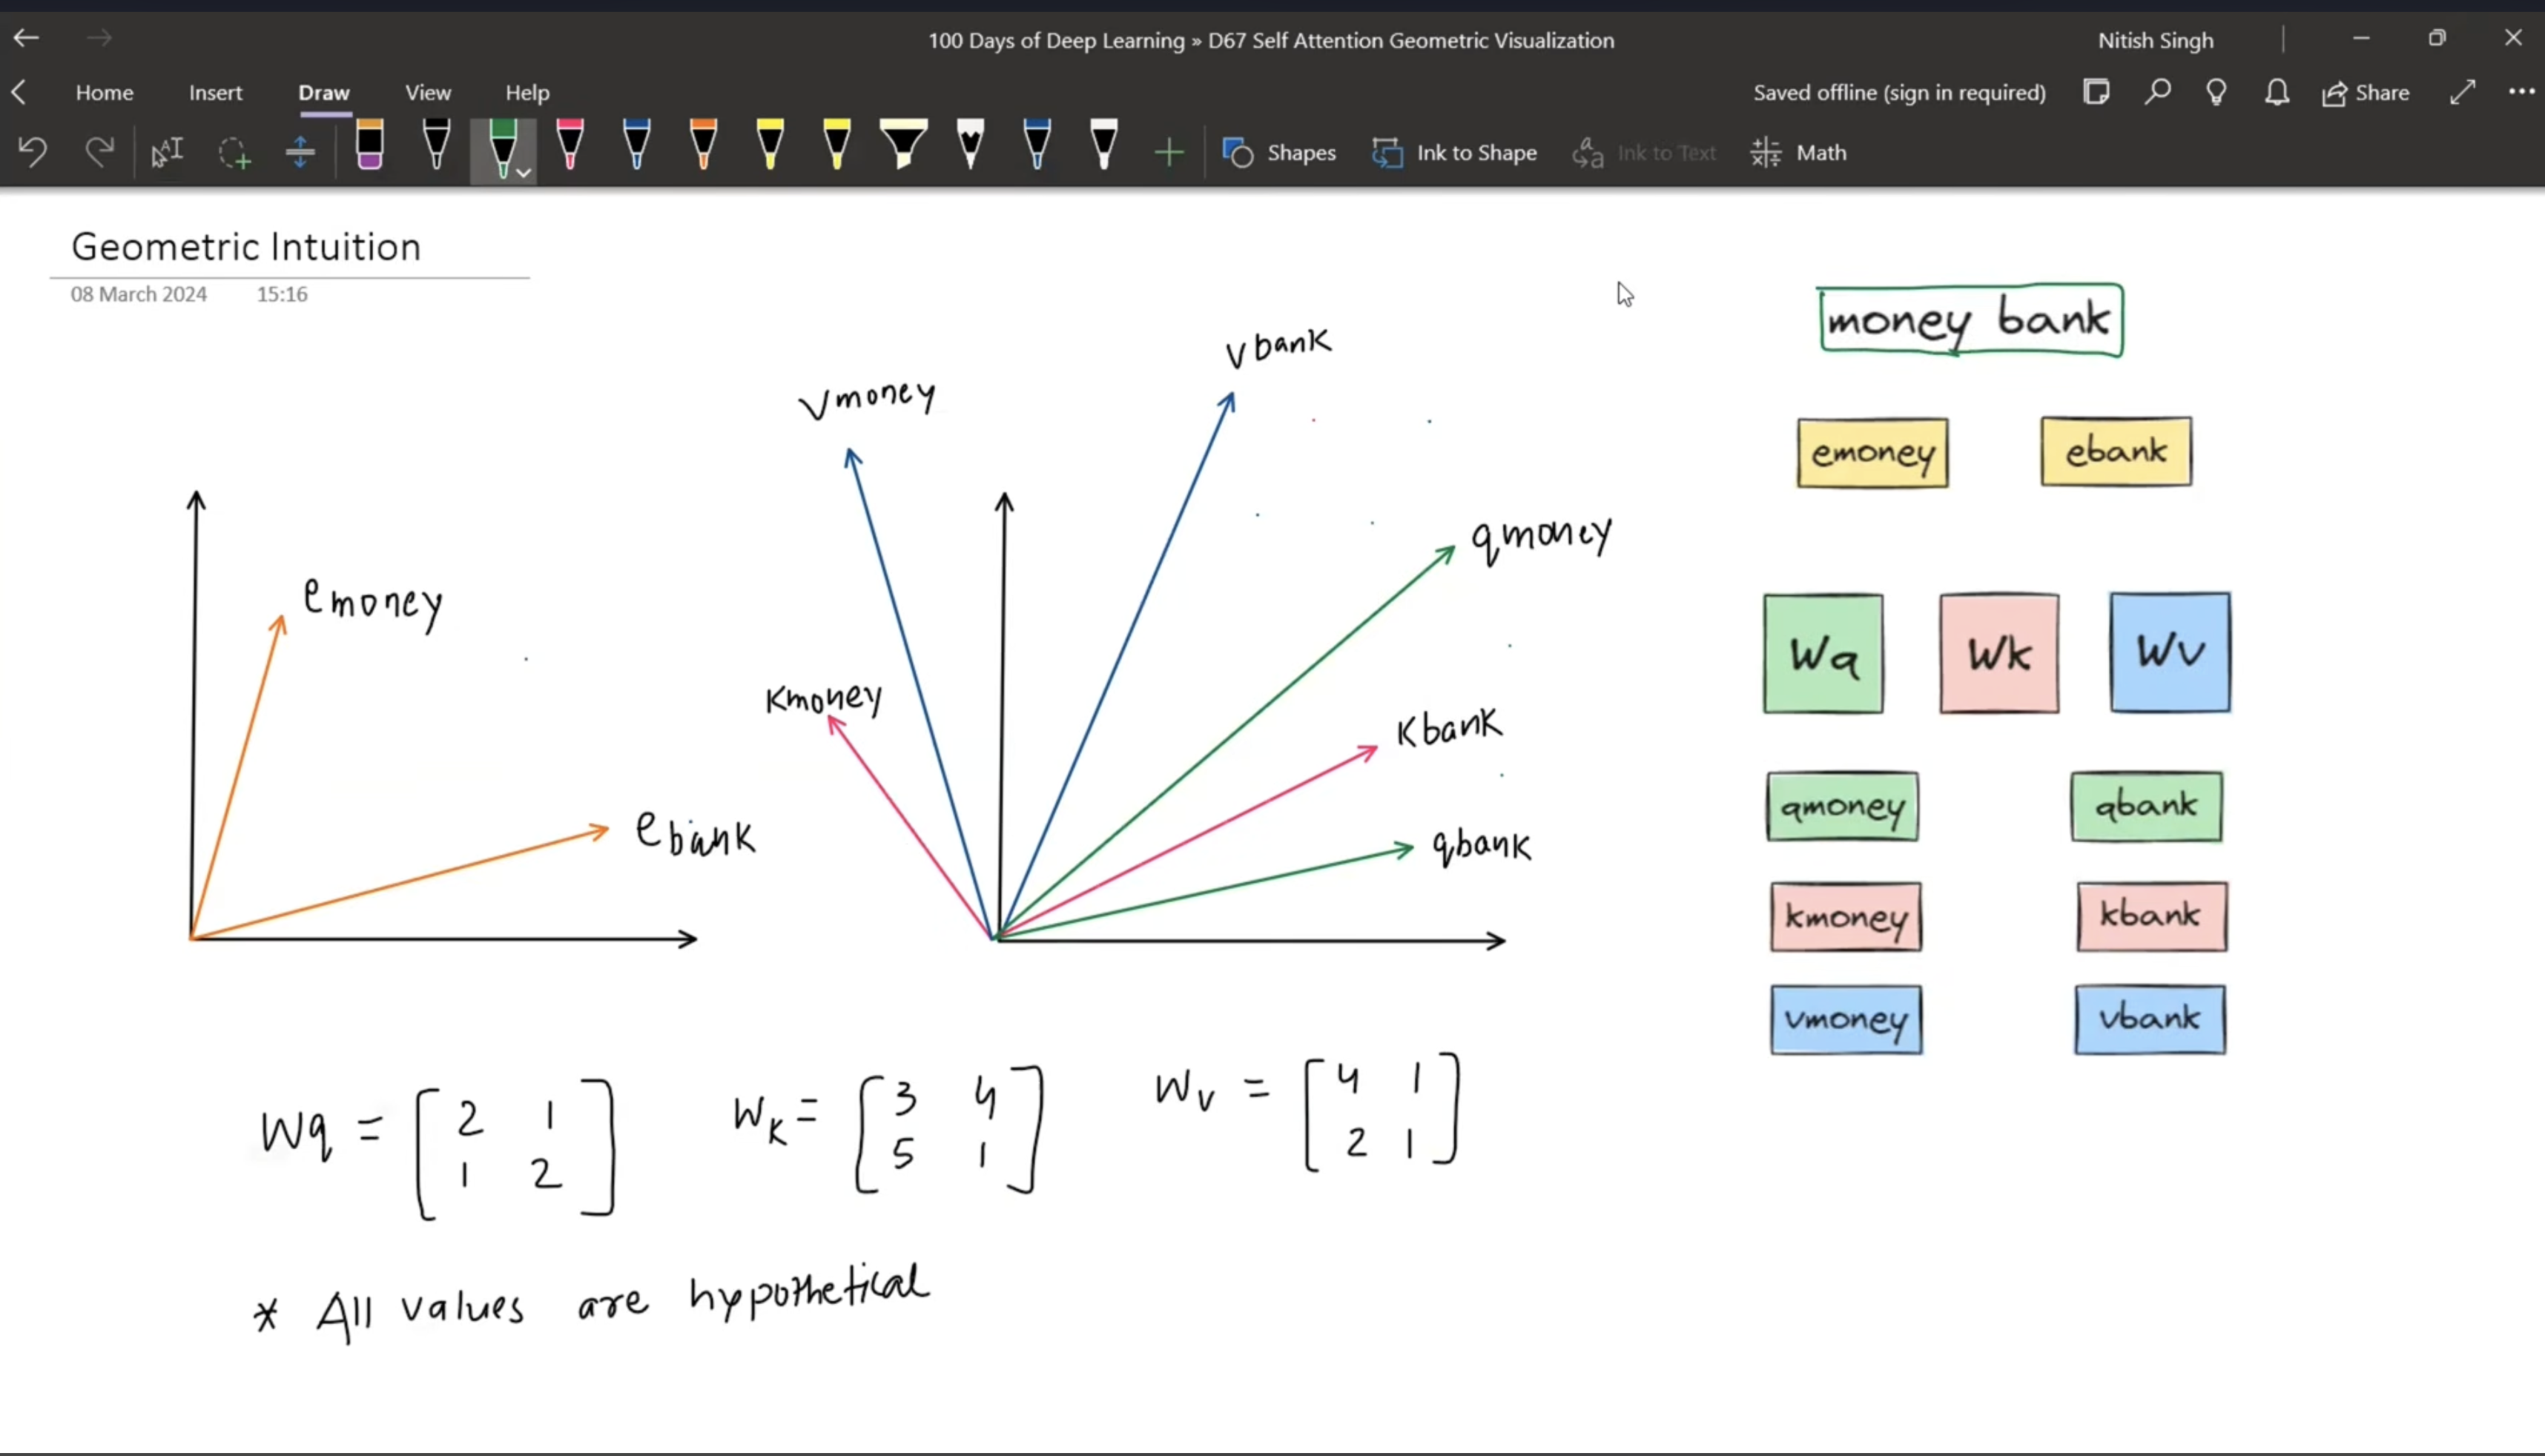
#### Step 0: The Starting Point – Word Embeddings

- Each word in your sentence is first converted into a **vector** (a list of numbers) using an embedding technique like Word2Vec.
- These vectors live in a high-dimensional space (e.g., 200 or 256 dimensions).
- **Key idea:** Words with similar meanings are located close to each other in this space.

**Example:**  
Sentence: *"Money Bank"*  
- `e_Money` = vector for "Money"  
- `e_Bank` = vector for "Bank"  

In our illustration, we use 2D vectors for easy visualization:
- e_Money = (2, 1)  
- e_Bank = (7, 3)

These are plotted as arrows (vectors) from the origin.

---

#### Step 1: Create Query (Q), Key (K), and Value (V) Vectors

For each word, we multiply its embedding vector by **three different matrices**:  
- **W_Q** (Query matrix)  
- **W_K** (Key matrix)  
- **W_V** (Value matrix)

These matrices are learned during training. For now, we assume hypothetical values.

**What happens geometrically?**  
Multiplying a vector by a matrix performs a **linear transformation** – it rotates, scales, or shifts the vector in space. So from one embedding vector, we create three new vectors pointing in different directions.

For "Money":  
- e_Money × W_Q → q_Money  
- e_Money × W_K → k_Money  
- e_Money × W_V → v_Money  

For "Bank":  
- e_Bank × W_Q → q_Bank  
- e_Bank × W_K → k_Bank  
- e_Bank × W_V → v_Bank  

Now we have **6 vectors** from the original 2.

---

#### Step 2: Compute Similarity (Dot Product)

To compute the context for "Bank", we take its **query vector (q_Bank)** and dot it with **all key vectors** (k_Money and k_Bank).

**Dot product = measure of similarity**  
- If two vectors point in the same direction → large positive dot product (high similarity)  
- If they are perpendicular → dot product = 0 (no similarity)  
- If they point in opposite directions → negative dot product (dissimilar)

Geometrically, the smaller the angle between vectors, the higher the dot product.

**Example values (hypothetical):**  
- q_Bank · k_Money = 10 (smaller similarity – larger angle)  
- q_Bank · k_Bank = 32 (higher similarity – smaller angle)

---

#### Step 3: Scale the Scores

We divide each score by **√d_k**, where d_k is the dimension of the key vectors.  
This prevents the dot products from becoming too large, which would push the softmax into regions with very small gradients.

Here, d_k = 2, so √d_k = √2 ≈ 1.41.

- Scaled score with Money = 10 / 1.41 ≈ 7.09  
- Scaled score with Bank = 32 / 1.41 ≈ 22.6

---

#### Step 4: Apply Softmax (Normalization)

Softmax converts the scores into probabilities (weights) that sum to 1.

**Purpose:**  
- The higher the score, the higher the weight.  
- The weights determine how much attention each word pays to the others.

**Example:**  
After softmax:  
- Weight for Money (w₂₁) = 0.2  
- Weight for Bank (w₂₂) = 0.8  
(Sum = 1.0)

So "Bank" attends 20% to "Money" and 80% to itself.

---

#### Step 5: Weighted Sum of Value Vectors

Now we take the **value vectors (v_Money, v_Bank)** and multiply each by its corresponding weight, then add them.

- Scaled v_Money = 0.2 × v_Money  
- Scaled v_Bank = 0.8 × v_Bank  

Then **vector addition**:  
**y_Bank = (0.2 × v_Money) + (0.8 × v_Bank)**

Geometrically:  
- First, shrink v_Money and v_Bank by their weights (scalar multiplication – changes length, not direction).  
- Then, place these scaled vectors head-to-tail (parallelogram law) and draw the resultant vector.

**Result:**  
The new contextual embedding y_Bank is **pulled closer** to the direction of v_Money because of the 20% contribution from Money.

---

#### The "Gravity" Analogy

Self-attention behaves like **gravity**:  
- The word "Money" exerts a "pull" on "Bank" because they are related in this sentence.  
- The new contextual vector y_Bank moves significantly closer to the embedding of "Money" than the original e_Bank was.

**Crucially:**  
If the sentence were *"River Bank"*, the "River" vector would pull "Bank" in a **different direction**. The same word "Bank" gets a different contextual embedding depending on its neighbors.

---

### 3. Key Points

- Self-attention transforms static embeddings into **context-aware** embeddings.
- The process uses **Query, Key, and Value** vectors derived from each word.
- **Dot product** measures similarity between Q and K vectors.
- **Scaling** and **Softmax** convert similarities into attention weights.
- The final output is a **weighted sum** of Value vectors.
- Geometrically, it's a sequence of:  
  *Linear transformations → Similarity computation → Normalization → Weighted averaging*.
- The output vector moves toward the vectors of semantically related words – like a gravitational pull.

---

### 4. Syntax / Structure

> *Note: This section is skipped because the transcript does not contain explicit code syntax or formal mathematical notation. The transcript is conceptual and visual.*

---

### 5. Code Examples

> *Note: The transcript does not include actual code; it only describes the process mathematically and visually. Therefore, this section is omitted as per instructions.*

---

### 6. Output

> *Note: The transcript does not show numerical output from a program. It uses hypothetical scalar values for illustration. Therefore, this section is skipped.*

---

### 7. Common Mistakes (and How to Avoid Them)

| Mistake | Explanation | How to Avoid |
|---------|-------------|---------------|
| Confusing Q, K, V roles | Beginners mix up which vector is used with which. | Remember: **Q**uery asks the question; **K**ey is what you compare against; **V**alue is what you average. |
| Thinking Q, K, V are fixed | They are not fixed – they are produced by multiplying embeddings with learned matrices. | Understand they are *projections* of the same embedding. |
| Forgetting the scaling step | Skipping ÷√d_k can make softmax outputs too extreme (one weight near 1, others near 0). | Always include scaling – it stabilizes training. |
| Assuming weights are the final output | The weights are intermediate; the final output is the weighted sum of V. | Focus on y (contextual embedding), not just the attention scores. |
| Not visualizing geometrically | Without visualization, the math feels abstract. | Use 2D analogies (as in this transcript) to build intuition before diving into high dimensions. |

---

### 8. Interview / Exam Questions

**Q1:** What is the purpose of self-attention in Transformers?  
**A:** To generate context-dependent embeddings by allowing each word to attend to all other words in the input sequence.

**Q2:** Explain the role of Query, Key, and Value vectors.  
**A:** Query represents the current word asking for information; Key represents what each word offers; Value is the actual content to be aggregated. The attention weight is computed from Q and K, then used to weight V.

**Q3:** Why do we divide the dot product by √d_k before softmax?  
**A:** To keep the magnitudes of the dot products in a reasonable range, preventing the softmax from becoming too "peaked" and causing vanishing gradients.

**Q4:** How does self-attention handle polysemy (words with multiple meanings)?  
**A:** It uses the surrounding words to adjust the embedding. In "money bank", "bank" is pulled toward financial words; in "river bank", it's pulled toward geographical words.

**Q5:** Can you describe the geometric interpretation of self-attention?  
**A:** It's a sequence of vector transformations: rotation/scaling (via Q, K, V matrices), similarity measurement (dot product), and weighted averaging (scaling + vector addition). The result is a vector that moves toward related words in the embedding space.

---

### 9. Revision Notes (Quick Recap)

- **Goal:** Convert static word vectors → context-aware vectors.
- **Steps:**
  1. Embedding → Q, K, V (via linear transformations).
  2. Similarity = Q · K (dot product).
  3. Scale by √d_k.
  4. Softmax → attention weights.
  5. Weighted sum of V → final contextual vector.
- **Geometric view:**
  - Embeddings are points/arrows in space.
  - Self-attention is like "gravity" – related words pull each other closer.
  - Same word moves to different regions depending on sentence context.
- **Why it matters:** Enables models to understand meaning based on context, not just isolated words.

---

**That concludes Topic 1.**  


## Topic 2: The Complete Self-Attention Flow – From Embeddings to Contextual Vectors
 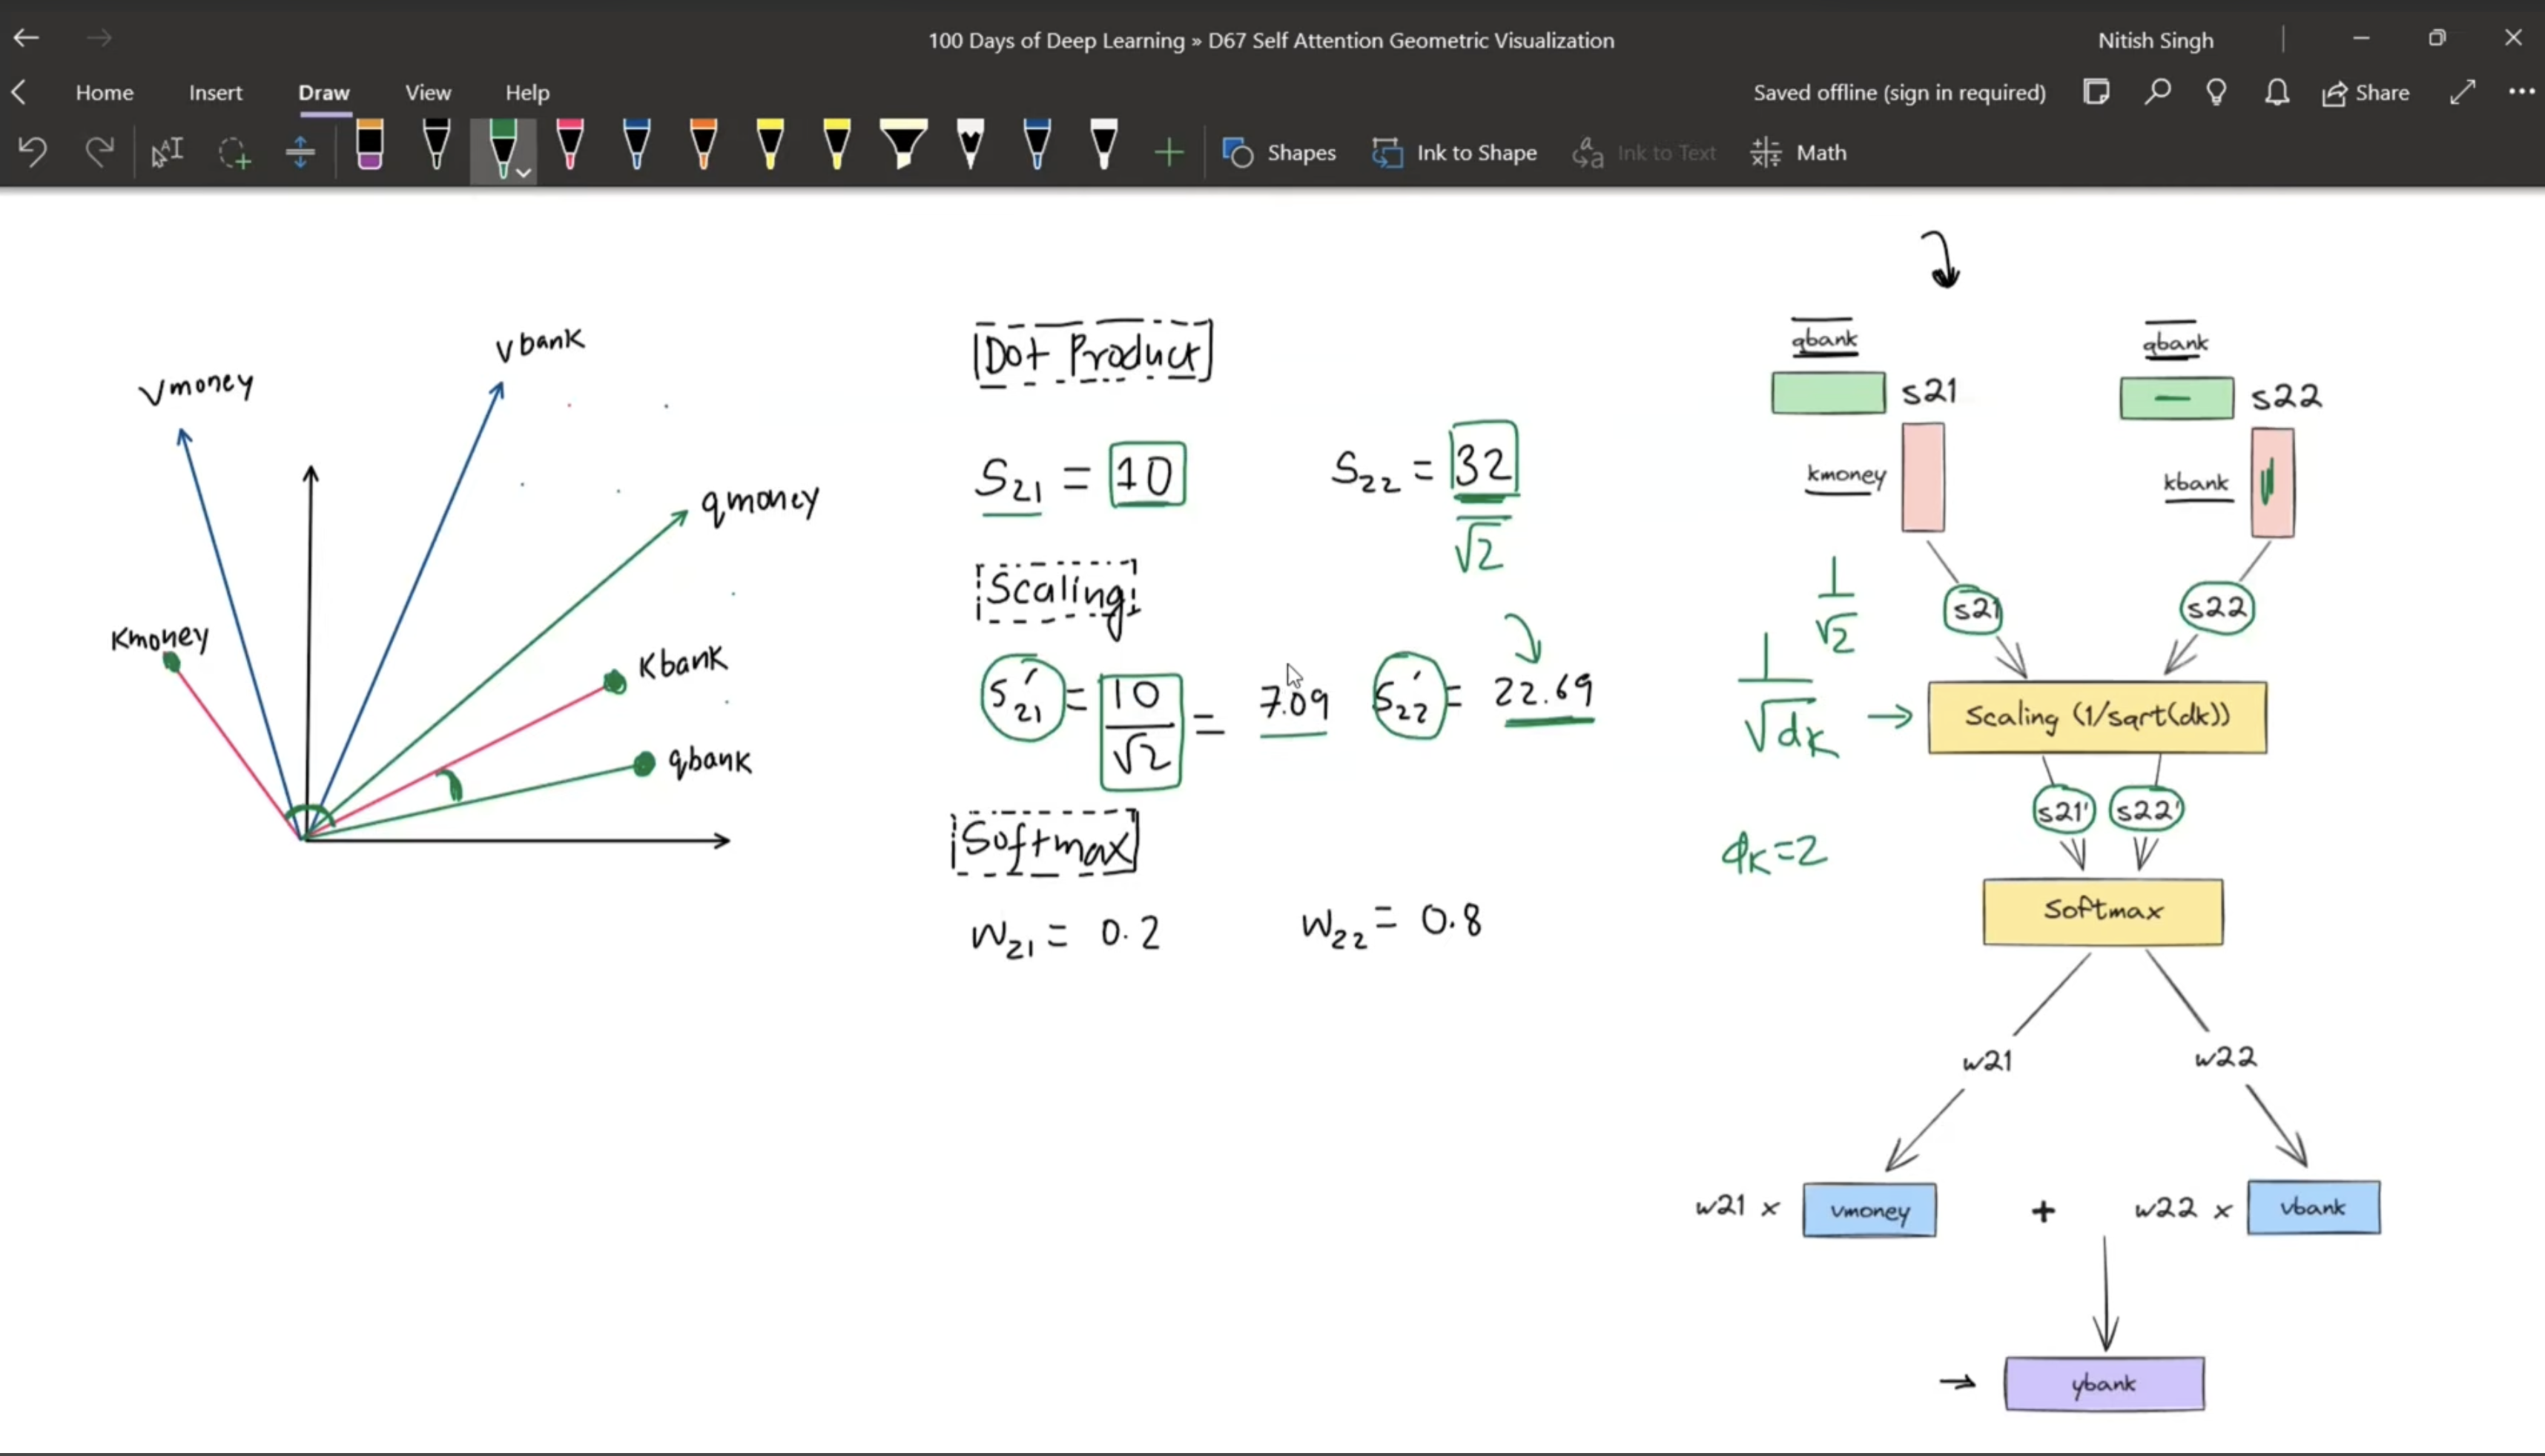
---

### 1. Introduction

**What it is:**  
This topic provides a **complete visual and mathematical walkthrough** of the entire self-attention pipeline — from the moment you have raw word embeddings to the final output of contextual embeddings for each word in a sentence.

**Why it's important:**  
Many learners understand the individual steps (Q, K, V, dot product, softmax, weighted sum) but fail to see how they connect into a **coherent flow**. This topic ties everything together, showing exactly which vectors are used at each stage and how they transform.

**Real-life use:**  
This is the actual mechanism running inside every Transformer-based model (BERT, GPT, T5, etc.) every time they process text — whether for translation, summarization, or question-answering.

---

### 2. Detailed Explanation (Step-by-Step)

We'll walk through the complete pipeline using the two-word sentence: **"Money Bank"**

---

#### Stage 1: Input Embeddings

We start with two words. Each is represented as a **d-dimensional vector** (here, d=2 for visualization).

- e_Money = vector for "Money"  
- e_Bank = vector for "Bank"

These are plotted as arrows from the origin in 2D space.

---

#### Stage 2: Generate Q, K, V for Each Word

We have three learned weight matrices:
- **W_Q** – generates Query vectors  
- **W_K** – generates Key vectors  
- **W_V** – generates Value vectors  

For **each** word embedding, we multiply by all three matrices:

| Word | Query | Key | Value |
|------|-------|-----|-------|
| Money | q_Money = e_Money × W_Q | k_Money = e_Money × W_K | v_Money = e_Money × W_V |
| Bank  | q_Bank  = e_Bank × W_Q  | k_Bank  = e_Bank × W_K  | v_Bank  = e_Bank × W_V  |

**Total:** 2 embeddings → 6 vectors.

**Geometric meaning:**  
Each original embedding gets **transformed** (rotated/scaled) into three new directions. These transformations are learned during training to optimize the attention mechanism.

---

#### Stage 3: Compute Attention Scores (for each target word)

To generate the contextual embedding for a specific word, we use its **Query** vector and compare it against **all Key** vectors.

**For y_Bank (contextual embedding of "Bank"):**

1. q_Bank · k_Money = similarity score with "Money"  
2. q_Bank · k_Bank = similarity score with "Bank" itself

**Hypothetical values used in the video:**
- q_Bank · k_Money = 10  
- q_Bank · k_Bank = 32

**Interpretation:**  
"Bank" is more similar to itself (32) than to "Money" (10), which makes sense — but the score with "Money" is not zero, so there is some relationship.

---

#### Stage 4: Scaling

Divide each score by **√d_k**, where d_k = dimension of Key vectors (here, 2).

- Scaled score with Money = 10 / √2 ≈ 7.09  
- Scaled score with Bank = 32 / √2 ≈ 22.6

**Why scale?**  
Without scaling, large dot products push softmax into regions with extremely small gradients, making training slow or unstable.

---

#### Stage 5: Softmax Normalization

Apply softmax to convert scores into probabilities (weights) that sum to 1.

- w₂₁ = weight from "Bank" to "Money" ≈ 0.2 (20%)  
- w₂₂ = weight from "Bank" to itself ≈ 0.8 (80%)

**Meaning:**  
When computing the new representation for "Bank", we'll use 20% of "Money's" value and 80% of "Bank's" own value.

---

#### Stage 6: Weighted Sum of Value Vectors

Now we use the **Value vectors** (v_Money and v_Bank) — not the original embeddings.

- Multiply v_Money by w₂₁ (0.2) → scales the vector down  
- Multiply v_Bank by w₂₂ (0.8) → scales it down (less than full, but more than v_Money)

Then perform **vector addition**:
```
y_Bank = (0.2 × v_Money) + (0.8 × v_Bank)
```

**Geometric steps in this stage:**

1. **Scalar multiplication** – changes the length of each vector without changing its direction.  
   - v_Money becomes shorter (20% of original length)  
   - v_Bank becomes shorter (80% of original length)

2. **Vector addition** – using the parallelogram law:  
   - Place the two scaled vectors tail-to-tail  
   - Complete the parallelogram  
   - Draw the diagonal from the origin — that diagonal is y_Bank

---

#### Stage 7: Compare with Original Embeddings

Now overlay the original embedding e_Bank with the new contextual embedding y_Bank.

**Observation:**  
- e_Bank was far from e_Money in the vector space  
- y_Bank has **moved significantly closer** to e_Money

This is the **"gravity" effect** — "Money" pulled "Bank" toward itself because they appear together in the sentence.

---

#### Stage 8: Symmetry – Both Words Get Updated

The same process is repeated for "Money":

```
y_Money = (w₁₁ × v_Money) + (w₁₂ × v_Bank)
```

Where:
- w₁₁ = attention from "Money" to itself  
- w₁₂ = attention from "Money" to "Bank"

So **both** words get new contextual embeddings. In a longer sentence, every word would attend to every other word, including itself.

---

#### The Big Picture

| Step | Operation | Input → Output |
|------|-----------|----------------|
| 1 | Embedding | Word → e_vector |
| 2 | Linear transforms | e → (q, k, v) |
| 3 | Dot product | q_target · k_all → scores |
| 4 | Scale | scores / √d_k |
| 5 | Softmax | scores → weights (sum=1) |
| 6 | Weighted sum | Σ(weights × v_all) → y_context |

---

### 3. Key Points

- The self-attention pipeline is **symmetrical**: each word generates its own Q, K, V, and each word's output depends on all words.
- The **Value vectors** carry the actual content to be aggregated; Query and Key only determine how much weight each Value gets.
- The final output is a **contextual embedding** that is a linear combination of all Value vectors.
- Geometrically, the output vector is **pulled** toward vectors of semantically related words.
- The entire process is **differentiable**, meaning it can be trained end-to-end using backpropagation.

---

### 4. Syntax / Structure

> *Skipped – the transcript does not provide formal notation or code syntax.*

---

### 5. Code Examples

> *Skipped – the transcript focuses on geometric visualization, not implementation.*

---

### 6. Output

> *Skipped – no programmatic outputs are shown; the "output" here is the final contextual vector y, which is described conceptually.*

---

### 7. Common Mistakes

| Mistake | Explanation | How to Avoid |
|---------|-------------|---------------|
| Thinking Q, K, V are the same as original embeddings | They are **projections** – different from the original embedding. | Remember: original embedding is multiplied by three *different* matrices to get Q, K, V. |
| Forgetting that both words get updated | Some think only one word gets a new embedding. | Self-attention computes a new vector for **every** word in the input. |
| Mixing up which Q goes with which K | For y_Bank, you use q_Bank with **all** k's (including k_Bank and k_Money). | The target word's Q is compared against **every** word's K. |
| Assuming weights come from Value vectors | Weights are derived from Q and K, not from V. | Q and K determine attention; V is what gets averaged. |
| Not visualizing the vector addition | Weighted sum feels abstract without a picture. | Draw scaled vectors and use parallelogram law to see the resultant. |

---

### 8. Interview / Exam Questions

**Q1:** Walk me through the self-attention computation for a single word in a sentence.  
**A:** (Describe steps 1–6 above in sequence.)

**Q2:** Why do we need both Query and Key? Can't we just use one?  
**A:** Query and Key are separate projections that allow the model to learn different relationships. The Query represents "what I'm looking for," and Key represents "what I offer." Having separate matrices gives the model more flexibility.

**Q3:** What happens if the sentence has more than two words?  
**A:** The process scales naturally. Each word's Query is dotted with **all** Keys (including its own), producing N scores for N words. Softmax gives N weights, and the output is the weighted sum of all N Value vectors.

**Q4:** What is the computational complexity of self-attention?  
**A:** O(n² · d), where n = sequence length and d = dimension. This is because every word attends to every other word. This quadratic cost is a major limitation for long sequences.

**Q5:** How does the "gravity" analogy help in understanding self-attention?  
**A:** It visualizes the pull that related words exert on each other in the embedding space. Stronger relationships (higher attention weights) cause a stronger pull, moving the contextual embedding closer to those related words.

---

### 9. Revision Notes (Quick Recap)

- **Full pipeline:**  
  Embeddings → Q, K, V → scores (Q·K) → scale → softmax → weights → weighted sum of V → contextual embeddings.

- **For each word:**  
  Use its Q, compare with all K's → get weights → use all V's to compute new vector.

- **Geometric summary:**  
  Start with static vectors → apply linear transforms → measure similarities via angles → normalize → average with scaling → get context-aware vectors that move toward related words.

- **Core insight:**  
  Self-attention is essentially a **dynamic, data-dependent averaging mechanism** that repositions word vectors based on their sentence context.

---

**That concludes Topic 2.**  


## Topic 3: The "Gravity" Effect and Context-Awareness in Self-Attention

---
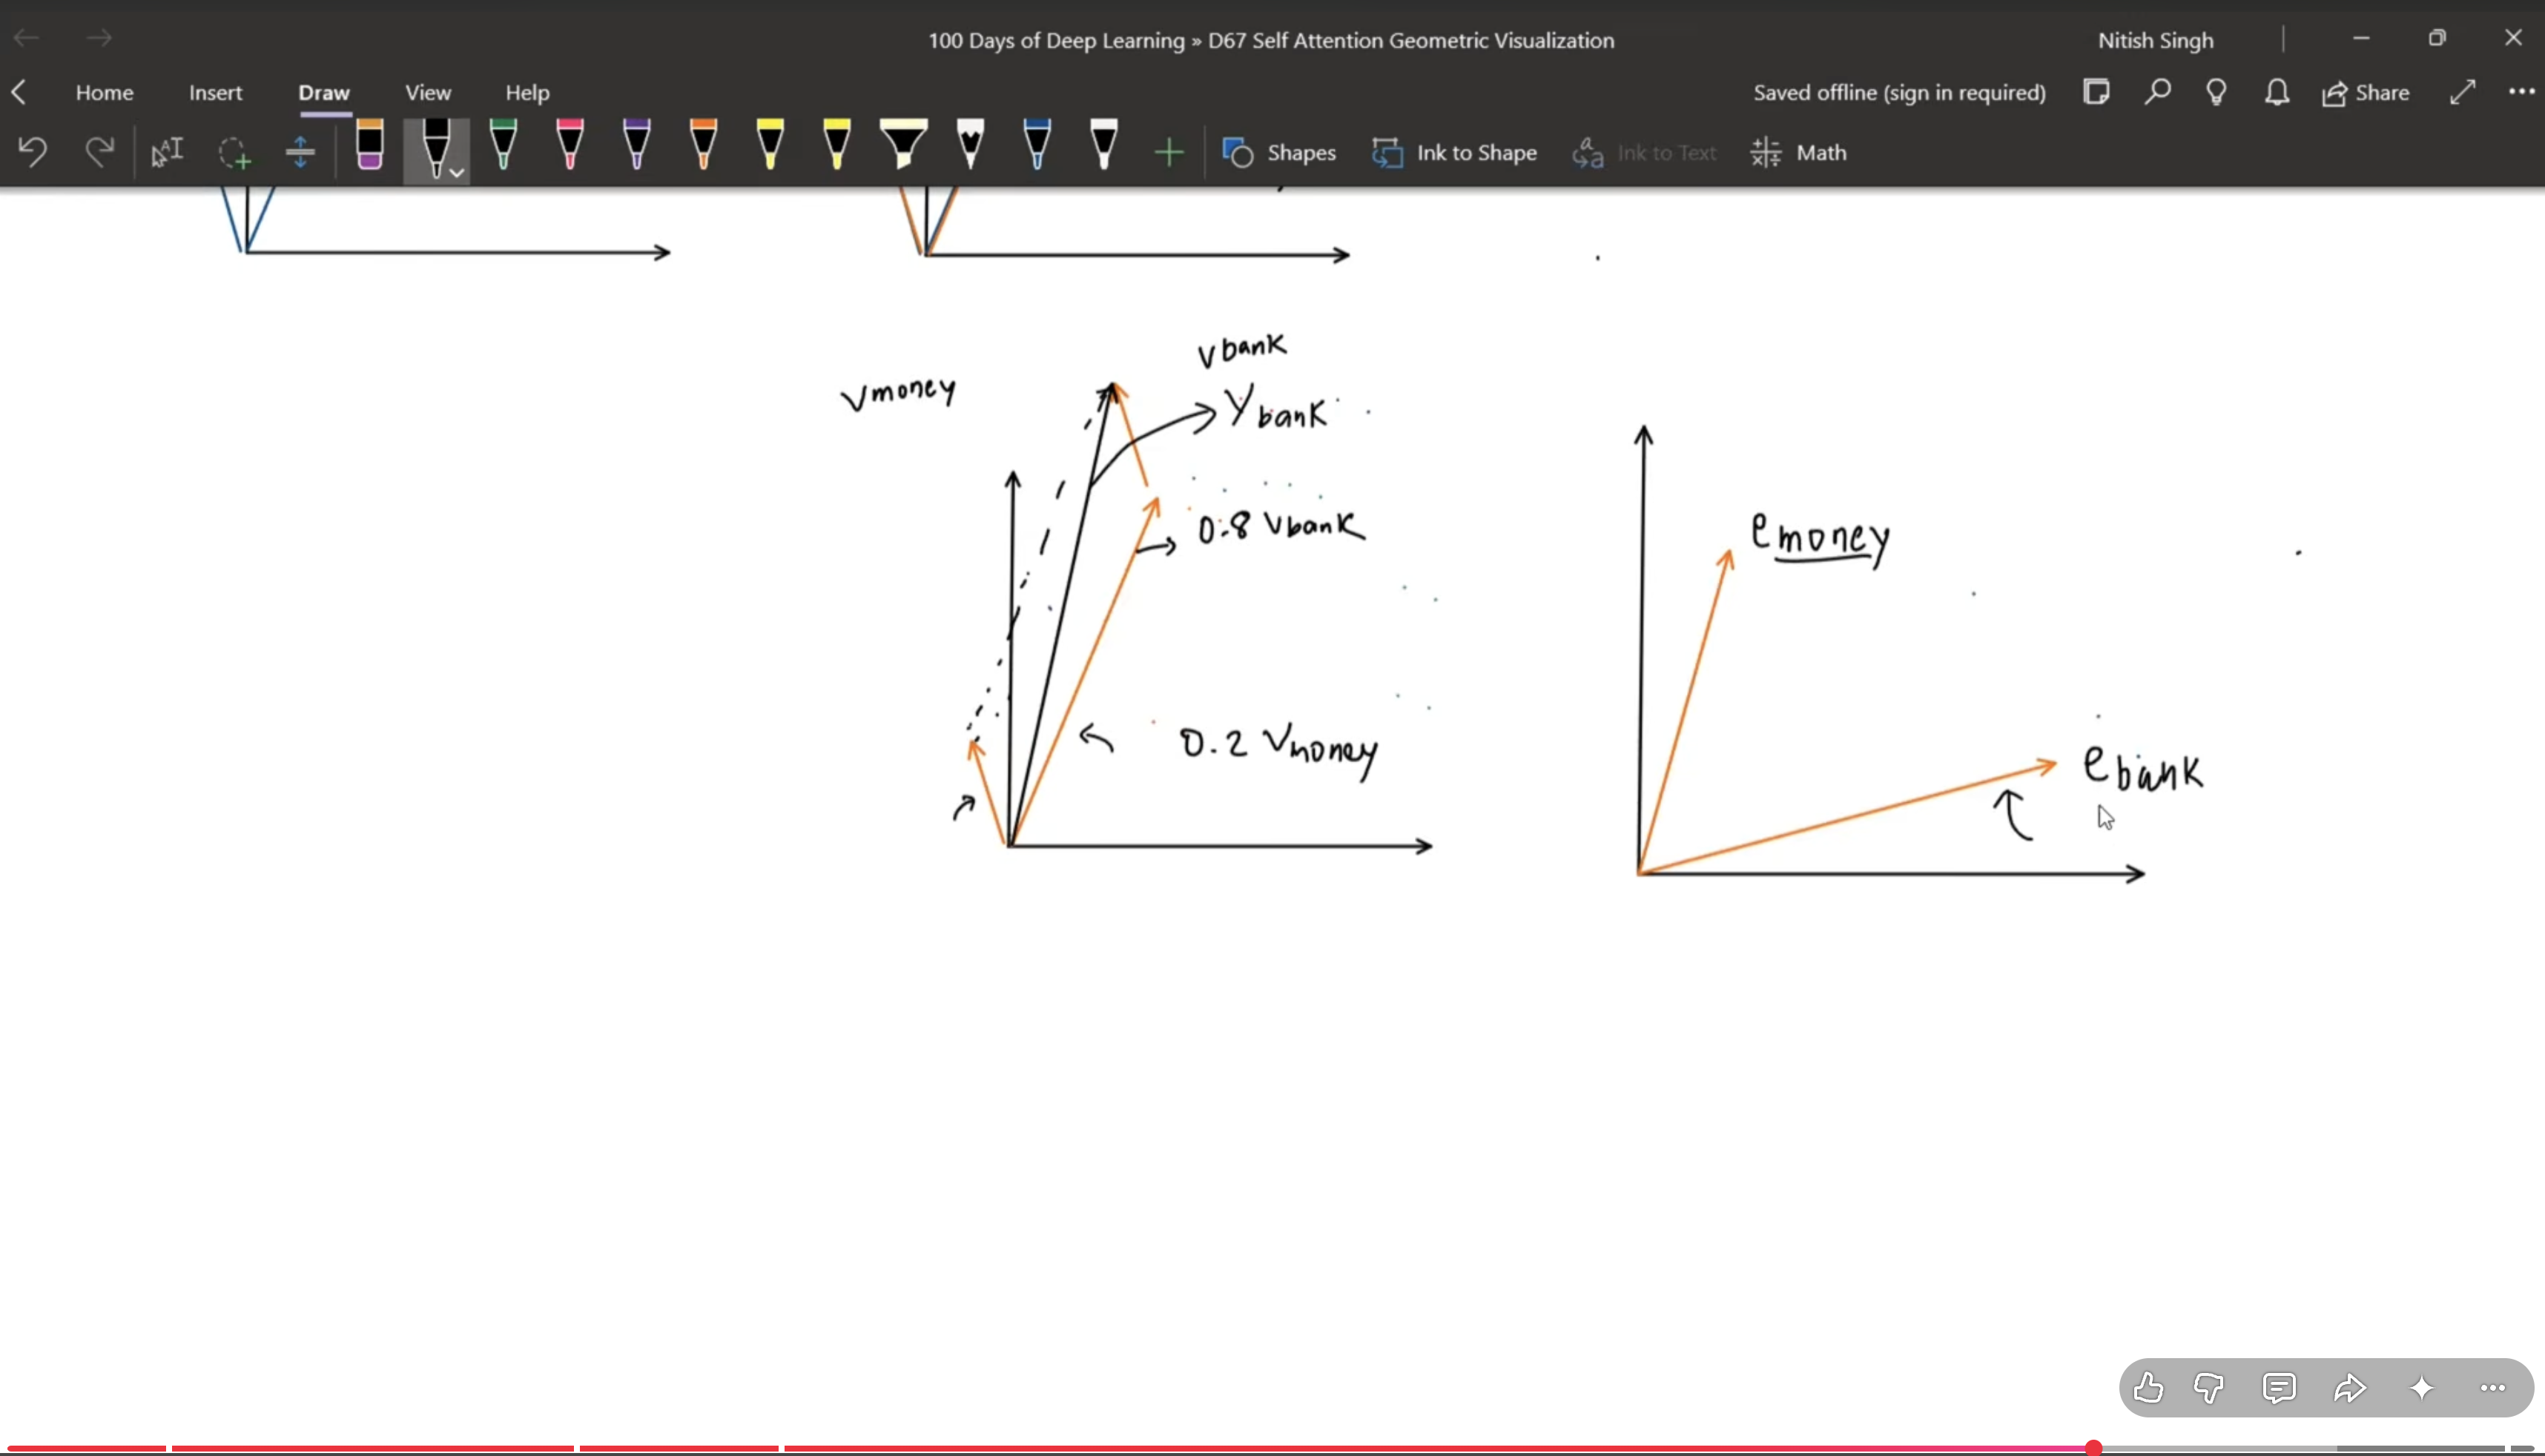
### 1. Introduction

**What it is:**  
The "gravity" effect is a powerful analogy to describe how self-attention pulls a word's embedding toward the embeddings of semantically related words in its sentence. This pull is **context-dependent** — the same word can be pulled in completely different directions depending on its neighboring words.

**Why it's important:**  
This is the **core reason** why Transformer models understand language so well. Static embeddings (like Word2Vec) treat "bank" the same everywhere. Self-attention dynamically adjusts "bank" to mean "financial institution" when paired with "money," and "river edge" when paired with "river." This context-awareness is what makes modern NLP so powerful.

**Real-life use:**  
- In machine translation, "bank" is translated as "banque" (French for financial bank) in "money bank," but as "rive" (riverbank) in "river bank."  
- In search engines, the same query word can retrieve different results based on surrounding query terms.  
- In chatbots, the system understands whether "apple" refers to fruit or technology based on context.

---

### 2. Detailed Explanation (Step-by-Step)

---

#### Part A: The Gravity Analogy Explained

**The Setup:**  
Imagine word embeddings as planets or stars in a high-dimensional space. Each word occupies a specific coordinate.

- **e_Money** sits at position (2, 1)  
- **e_Bank** sits at position (7, 3)  

These positions are fixed for static embeddings — they never change regardless of sentence context.

**What Self-Attention Does:**  
When "Bank" appears with "Money," self-attention computes a **new position** for "Bank" — its contextual embedding **y_Bank**. This new position is calculated as a weighted average of Value vectors, but geometrically, it appears as if "Money" has exerted a **gravitational pull** on "Bank."

**The Pull Effect:**  
- The original e_Bank was far away from e_Money.  
- After self-attention, y_Bank moves **significantly closer** to e_Money.  
- The strength of the pull depends on the attention weight — the higher the weight, the stronger the pull.

In our example:
- Weight from "Bank" to "Money" = 0.2 (20%)  
- Weight from "Bank" to itself = 0.8 (80%)  

So "Money" pulls "Bank" by 20% of the distance toward itself. The result is a new vector that is closer to "Money" than the original "Bank" was.

---

#### Part B: Context-Awareness – The Same Word, Different Pull

This is where things get fascinating.

**Scenario 1: "Money Bank"**  
- e_Money is located somewhere in the financial/economic region of the embedding space.  
- e_Bank is a generic embedding — perhaps slightly financial but not strongly so.  
- Self-attention: "Money" pulls "Bank" **toward the financial region**.  
- **Result:** y_Bank moves close to e_Money → now "Bank" is interpreted as a financial institution.

**Scenario 2: "River Bank"**  
- e_River is located in the geographical/nature region of the embedding space.  
- e_Bank is the same generic embedding as before (because embeddings are static).  
- Self-attention: "River" pulls "Bank" **toward the geographical region**.  
- **Result:** y_Bank moves close to e_River → now "Bank" is interpreted as the edge of a river.

**Visualizing the Difference:**

```
                     Financial Region          Geographical Region
                         (Money)                    (River)
                            ↑                          ↑
                            |                          |
    Before:  e_Bank -------→|        e_Bank ---------→|
                            |                          |
    After:   y_Bank --------→|        y_Bank ---------→|
                         (pulled toward Money)    (pulled toward River)
```

**Key Insight:**  
The **same input embedding** for "Bank" can produce **two entirely different output embeddings** depending on which words it co-occurs with. The attention mechanism decides the direction and magnitude of the pull based on the context.

---

#### Part C: Why Does This Happen?

This happens because self-attention is **data-driven**.

1. **Training Phase:**  
   The model sees millions of sentences. In sentences like "money bank," the attention weights between "money" and "bank" become high because they frequently co-occur. In sentences like "river bank," the weights between "river" and "bank" become high.

2. **Inference Phase (when using the trained model):**  
   When you feed a new sentence, the model computes attention weights based on the **learned patterns**. It has learned that "money" and "bank" are related in certain contexts, so it assigns a high weight and pulls "bank" accordingly.

3. **Geometric Outcome:**  
   The Value vectors (which are projections of the original embeddings) determine the actual direction of the pull. Since the model has learned different Value projections for different contexts, the pull direction changes.

---

#### Part D: The Two-Way Pull

Self-attention is **symmetrical** in its pull effect:

- "Money" pulls "Bank" toward itself.  
- **Simultaneously,** "Bank" pulls "Money" toward itself.

So both words move closer to each other in the embedding space.

**Why both directions?**  
Because context is mutual. "Money" provides context for "Bank," and "Bank" also provides context for "Money." In a sentence like "money laundering," "money" is pulled toward crime-related terms because of "laundering." So the pull is always bidirectional.

**Mathematical representation:**  
```
y_Money = (w₁₁ × v_Money) + (w₁₂ × v_Bank)
y_Bank  = (w₂₁ × v_Money) + (w₂₂ × v_Bank)
```

Both equations include contributions from the other word, so both vectors move.

---

#### Part E: The Bigger Picture – Long Sentences

In a sentence with 10 words, each word is pulled in **10 different directions** simultaneously, with varying strengths.

- Words that are highly related → strong pull → large weight.  
- Words that are unrelated → weak pull → small weight.  
- The word itself → moderate pull (usually the highest weight goes to itself, but not always).

**Result:**  
Each word's final embedding is a **compromise position** — it moves toward the cluster of words that are semantically relevant to it, while staying somewhat anchored to its original meaning.

This is why self-attention is so powerful: it creates a **dynamic embedding space** where word positions are re-computed for every single sentence.

---

### 3. Key Points

- Self-attention acts like **gravity**: related words pull each other closer in the embedding space.
- The **strength of the pull** is determined by the attention weight (from softmax).
- The **direction of the pull** is determined by the Value vectors.
- The **same word** can be pulled in completely different directions depending on its sentence context.
- The pull is **bidirectional** — all words pull each other simultaneously.
- This context-awareness is the **fundamental reason** Transformers outperform static embedding models.
- The entire mechanism is **learned from data** — the model discovers which words are related based on patterns in the training corpus.

---

### 4. Syntax / Structure

> *Skipped — no syntax is discussed in this conceptual segment.*

---

### 5. Code Examples

> *Skipped — the transcript does not include code.*

---

### 6. Output

> *Skipped — the "output" here is the conceptual shift in embedding positions, not a numeric output.*

---

### 7. Common Mistakes

| Mistake | Explanation | How to Avoid |
|---------|-------------|---------------|
| Thinking the pull is literal physical gravity | It's an analogy — vectors don't physically "move"; they are recomputed mathematically. | Use the analogy to build intuition, but remember it's a weighted sum of vectors. |
| Assuming the pull is only one-way | Many beginners think only one word gets pulled. | Both words pull each other — attention is computed for every word. |
| Thinking the pull direction comes from the original embedding | The direction comes from the **Value vector**, not the original embedding. | Remember: V is a learned projection of the original embedding. |
| Believing the pull is fixed | The pull depends entirely on the sentence. | Same word can have different pulls in different contexts. |
| Ignoring the role of training data | The model learns which pulls are "correct" from data. | The model has no innate knowledge — it learns patterns from millions of examples. |

---

### 8. Interview / Exam Questions

**Q1:** Explain the "gravity" analogy for self-attention.  
**A:** Self-attention pulls a word's embedding toward the embeddings of related words in the sentence, similar to how gravity pulls objects toward each other. The pull strength comes from attention weights.

**Q2:** How does self-attention handle polysemy (words with multiple meanings)?  
**A:** It uses context: in "money bank," "bank" is pulled toward financial terms; in "river bank," it's pulled toward geographical terms. The same input embedding yields different output embeddings based on the surrounding words.

**Q3:** Is the pull one-way or two-way?  
**A:** Two-way. Every word attends to every other word, so all words pull each other simultaneously.

**Q4:** What determines the strength and direction of the pull?  
**A:** Strength comes from the attention weight (softmax output). Direction comes from the Value vector (which is a learned projection).

**Q5:** Why is this context-awareness important in real-world applications?  
**A:** It allows models to correctly interpret ambiguous words, leading to better translation, search, summarization, and conversation understanding.

**Q6:** Can the same word have completely different contextual embeddings?  
**A:** Yes — that's the entire point. "Bank" in "money bank" and "river bank" will have very different y vectors after self-attention.

---

### 9. Revision Notes (Quick Recap)

- **Gravity analogy:** Related words pull each other closer in embedding space.
- **Pull strength:** Determined by attention weight (0 to 1, sum=1 across all words).
- **Pull direction:** Determined by Value vector (projection of original embedding).
- **Context-awareness:** Same word → different pull direction depending on neighbors.
- **Two-way pull:** All words pull each other — no word is isolated.
- **Learning:** The model learns the pull patterns from training data.
- **Result:** Dynamic, sentence-specific embeddings that capture meaning far better than static embeddings.

---

### Final Summary of All Topics

| Topic | Core Idea |
|-------|-----------|
| **1. Geometric Intuition** | Self-attention is a sequence of vector transformations: embedding → Q, K, V → scores → weights → weighted sum. |
| **2. Complete Flow** | Step-by-step pipeline from input embeddings to contextual outputs, including scaling and softmax. |
| **3. Gravity & Context** | Self-attention dynamically pulls word embeddings toward related words; context determines the direction. |

---

**This concludes all topics from the transcript.**  
